In [2]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

import numpy as np
import matplotlib.pyplot as plt
from random import randint

from src.SemiArtifficialTrainDataGenerator import SemiArtifficialTrainDataGenerator
from src.FeatureEnhancer import FeatureEnhancer

model_path = "data/pigment_palette/subtracted_residual_spectra_heuristic.npz"

print("Loading model spectra...")
model_spectra = np.load(model_path)

model_spectra = {
    k: v 
    for k, v in model_spectra.items()
}

for k, v in model_spectra.items():
    lower, upper = np.nonzero(v)[0][0], np.nonzero(v)[0][-1]
    model_spectra[k][lower:upper] += np.exp(-np.linspace(4, 5, model_spectra[k][lower:upper].shape[-1]))
    model_spectra[k] /= np.max(model_spectra[k])

X, y = SemiArtifficialTrainDataGenerator.generate_artificial_data(
    spectra_samples=model_spectra,
    samples_count=10000
)


Loading model spectra...
{'mn', 'hg', 'pb', 'as', 'k', 'zr', 'ca', 'cr', 'ti', 'zn', 'ba', 'co', 'au', 'cd', 'fe', 'cu'}


100%|██████████| 10000/10000 [00:00<00:00, 17710.32it/s]


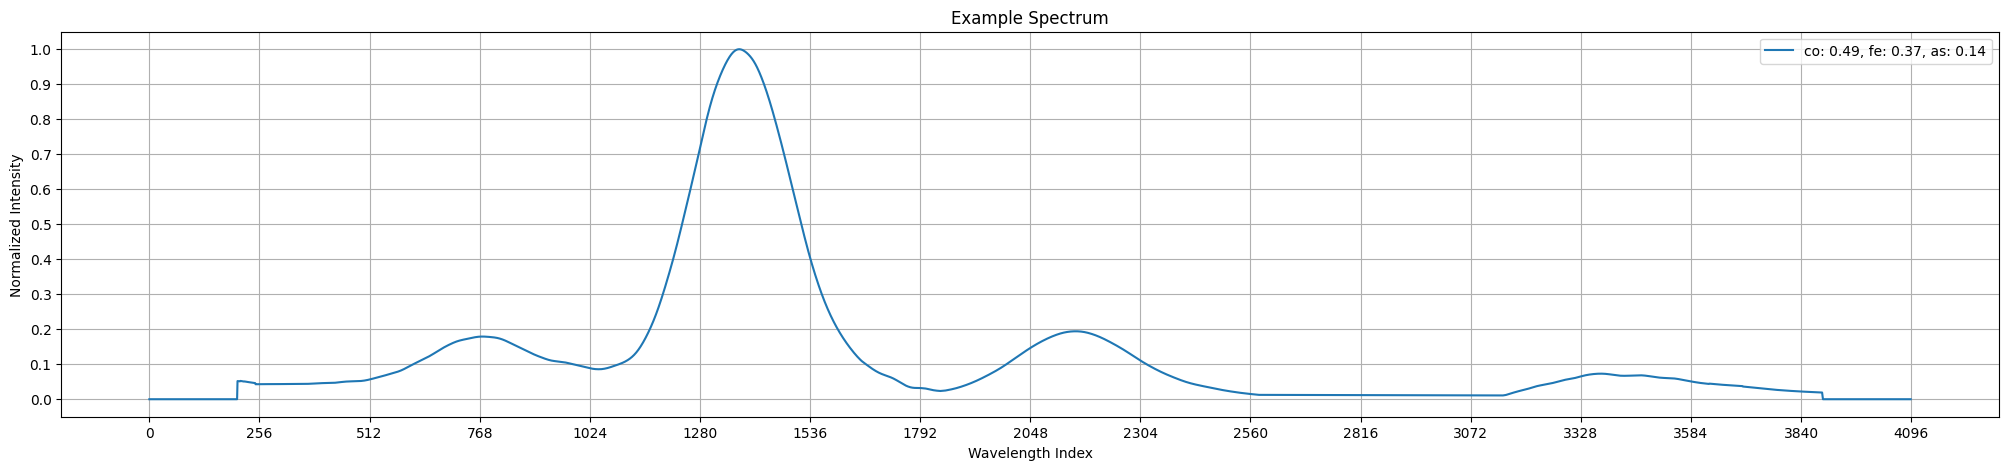

In [3]:
from src.Elements import Elements

idx = randint(0, 100) 
plt.figure(figsize=(25, 5))
label = {Elements.NUM2SYMBOL[i]: round(float(y[idx][i]), 2) for i in range(len(y[idx])) if float(y[idx][i]) > 0}
label = sorted(label.items(), key=lambda kv: kv[1], reverse=True)
label = ", ".join([f"{x[0]}: {x[1]}" for x in label])
plt.plot(X[idx], label=f"{label}")
plt.title("Example Spectrum")
plt.xlabel("Wavelength Index")
plt.ylabel("Normalized Intensity")
plt.legend()
plt.grid(True)
plt.xticks(range(0, X.shape[-1] + 1, 256))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.show()


In [4]:
X = FeatureEnhancer.process_spectra(X)

100%|██████████| 3/3 [00:00<00:00, 33825.03it/s]


/tmp/ipykernel_1246/4221448962.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


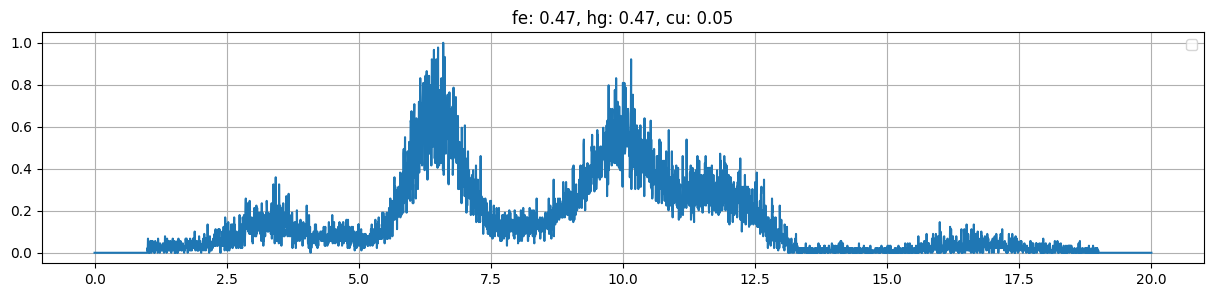

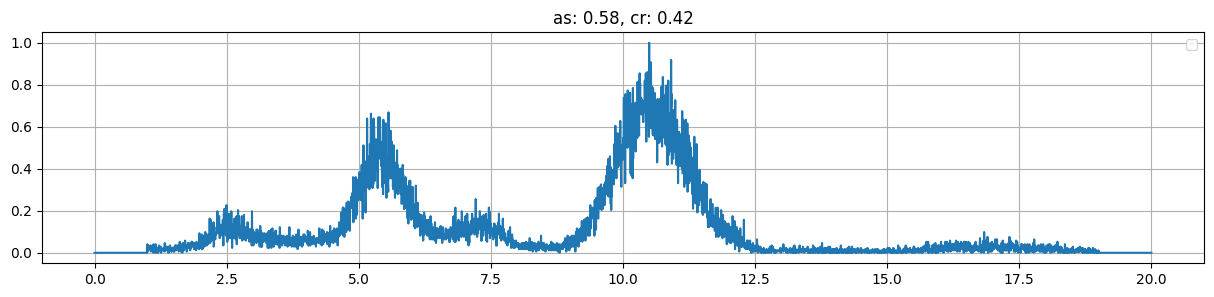

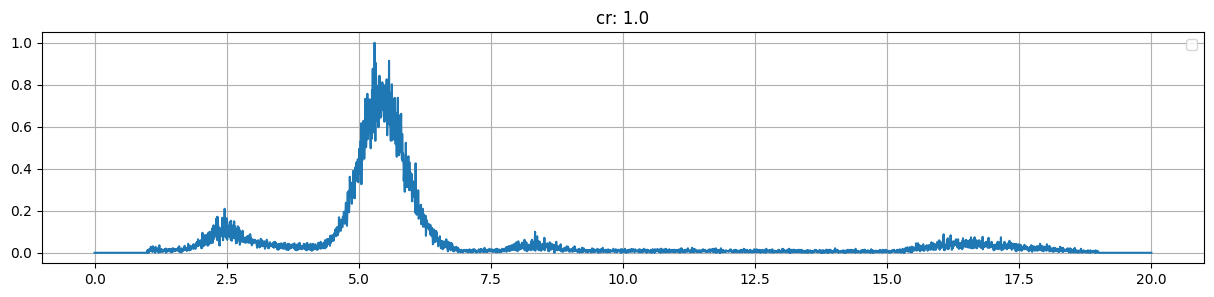

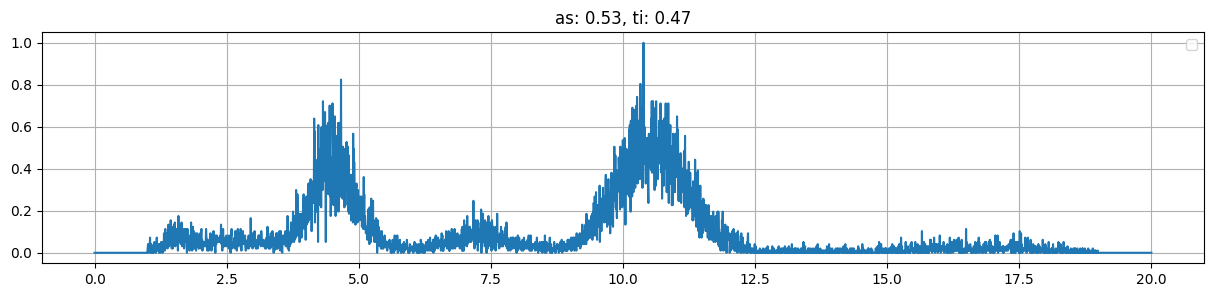

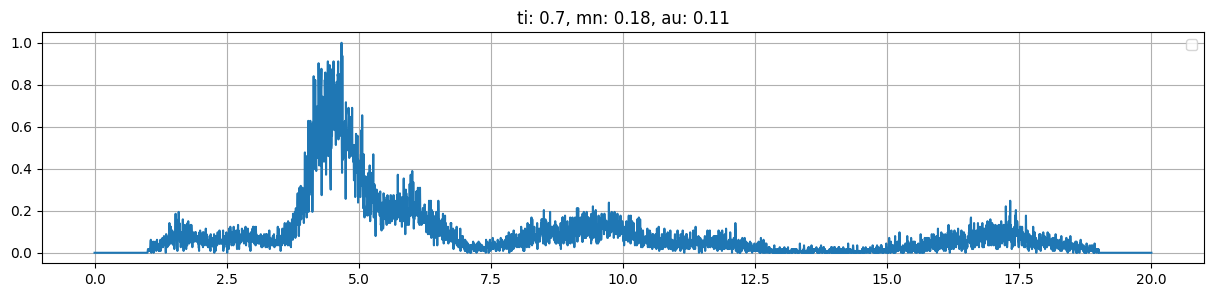

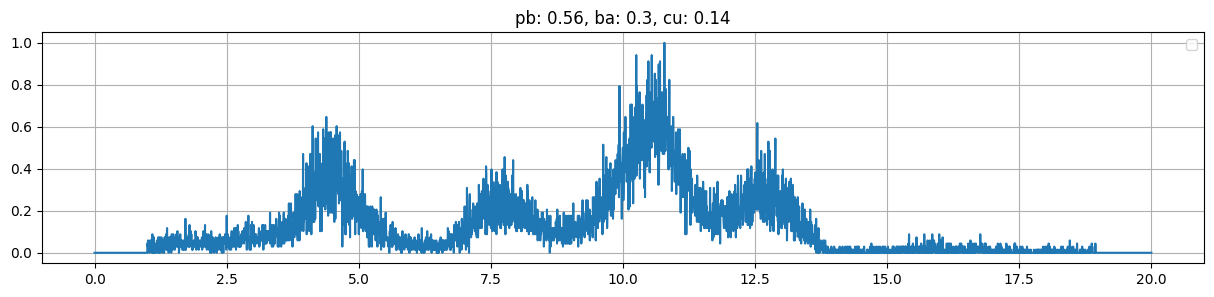

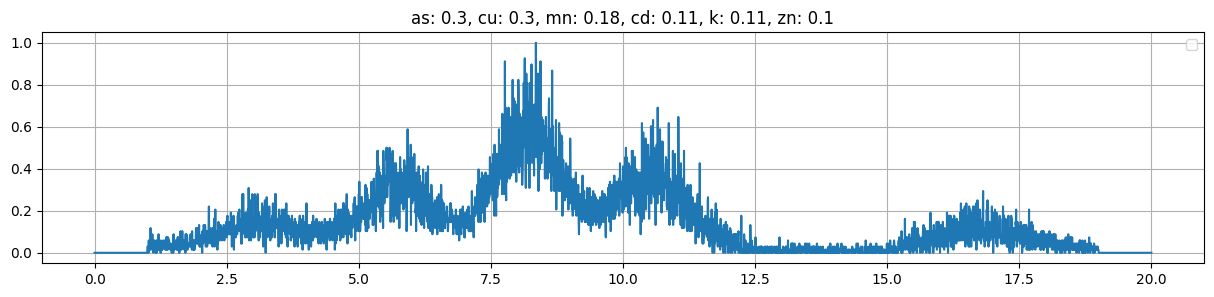

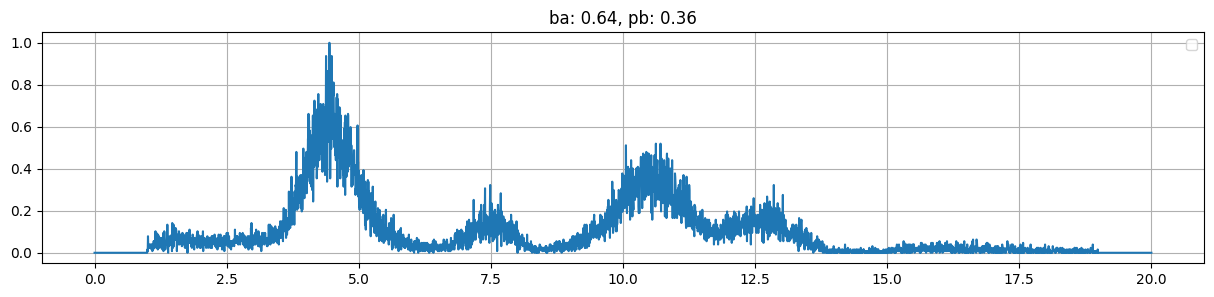

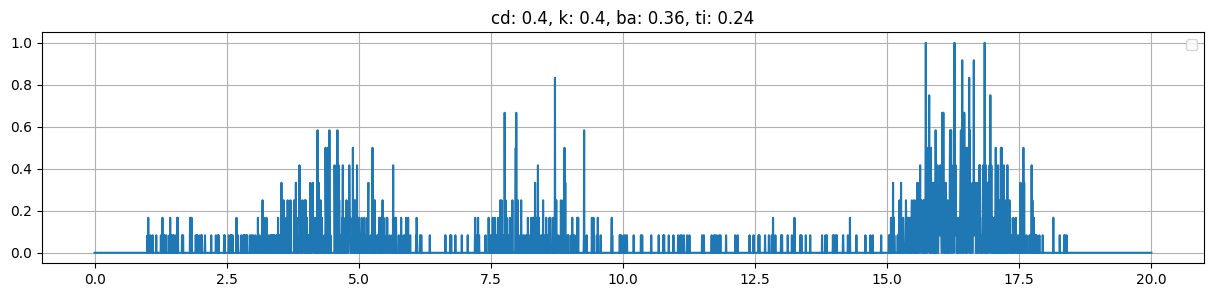

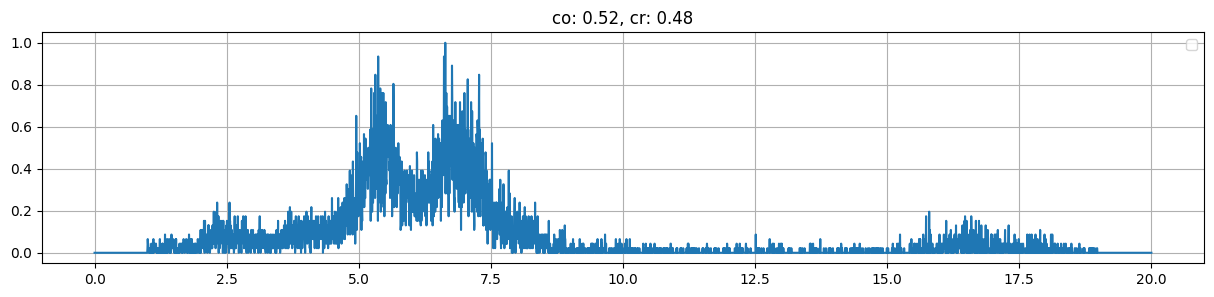

In [5]:
from src.Elements import Elements

for i in range(10):
    idx = randint(0, len(X) - 1)
    plt.figure(figsize=(15, 3))
    label = {Elements.NUM2SYMBOL[i]: round(float(y[idx][i]), 2) for i in range(len(y[idx])) if float(y[idx][i]) > 0}
    label = sorted(label.items(), key=lambda kv: kv[1], reverse=True)
    label = ", ".join([f"{x[0]}: {x[1]}" for x in label])
    plt.plot(np.linspace(0, 20, 4096), X[idx])
    plt.title(label)
    plt.legend()
    plt.grid(True)
    plt.show()



In [6]:
output_dir = "data/semi_artifficial_test"

np.save(f"{output_dir}/X.npy", X)
np.save(f"{output_dir}/y.npy", y)

[3 8 5 ... 3 3 5]


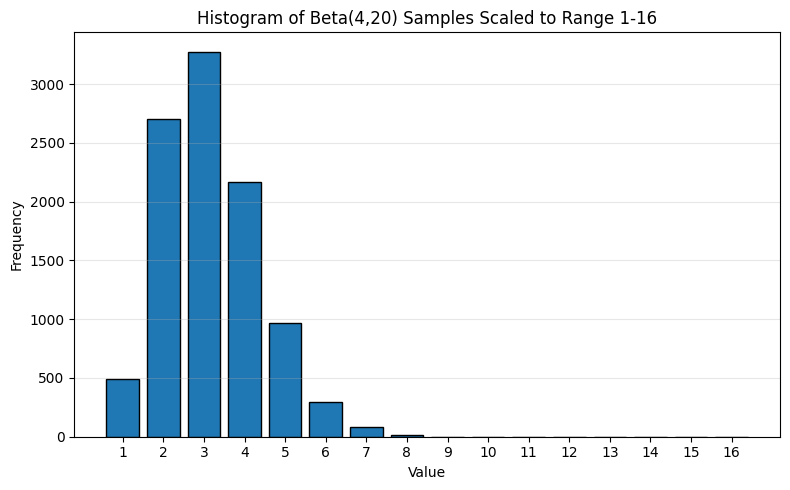

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# Parameters
N = 16
size = 10000

# Generate samples
samples_cont = beta.rvs(a=4, b=20, size=size)
samples = np.clip((samples_cont * N).astype(int) + 1, 1, N)
print(samples)

# Plot histogram
plt.figure(figsize=(8, 5))
plt.hist(samples, bins=np.arange(1, N + 2) - 0.5, edgecolor='black', rwidth=0.8)
plt.xticks(np.arange(1, N + 1))
plt.title("Histogram of Beta(4,20) Samples Scaled to Range 1-16")
plt.xlabel("Value")
plt.ylabel("Frequency")
# plt.yscale("log")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()